In [2]:
import sys
sys.path.insert(0, '..')
from model.data import getMyData
from model.embedding import DataEmbedding
from model.encoder import EncoderInf, ConvLayer, EncoderInfLayer
from model.attention import AttentionLayer,ProbAttention

import torch_ep.embed as epEmbed
import torch_ep.encoder as epEncoder
import torch

import os
import re

import numpy  as np
import tensorflow as tf
import math
import pandas as pd

from tensorflow.keras.layers import Dense
from keras.backend import softmax

import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so

In [4]:
# Get Features from ETTh1
def getDataETTh1(batch_size, seq_len, global_size):
    root_path = "../../data/"
    data_path = "ETTh1.csv"
    df_raw = pd.read_csv(os.path.join(root_path,data_path))

    # split = re.compile('-|:| ')
    # featuresDate = (df_raw['date'].str.split(split, expand=True)).astype(np.int64).iloc[:,:4]
    featuresData = df_raw.iloc[:,1:8].astype(np.float32)

    # On ajoute les infos temporelles : mois/jour/joursemain/heure
    df_raw['mois'] = df_raw.date.apply(lambda row:int(row[5:7])).astype(np.int64)
    df_raw['jour'] = df_raw.date.apply(lambda row:int(row[8:10])).astype(np.int64)
    df_raw['heure'] = df_raw.date.apply(lambda row:int(row[11:13])).astype(np.int64)
    df_raw['sJour'] = df_raw['date'].astype('datetime64[s]').dt.dayofweek.astype(np.int64)
    featuresDate = df_raw[['mois','jour','sJour','heure']].astype(np.int64)
    # featuresDate.describe()

    # Convert Features to numpy array
    featuresData = featuresData.to_numpy()
    featuresDate = featuresDate.to_numpy()
    # Create a dataset Feature Data
    X = np.array([featuresData[i:i+seq_len] for i in range(0, featuresData.shape[0]-seq_len)], dtype=np.float32)
    Y = np.array([featuresData[i+seq_len] for i in range(0, featuresData.shape[0]-seq_len-1)], dtype=np.float32)
    Xt = tf.convert_to_tensor(X[:global_size,:,:], dtype=tf.float32)
    Yt = tf.convert_to_tensor(Y[:global_size,:], dtype=tf.float32)
    XT = torch.from_numpy(X[:global_size,:,:])

    # Create a dataset : Features Date
    X = np.array([featuresDate[i:i+seq_len] for i in range(0, featuresDate.shape[0]-seq_len)], dtype=np.float32)
    Y = np.array([featuresDate[i+seq_len] for i in range(0, featuresDate.shape[0]-seq_len-1)], dtype=np.float32)
    XtDate = tf.convert_to_tensor(X[:global_size,:,:], dtype=tf.float32)
    YtDate = tf.convert_to_tensor(Y[:global_size,:], dtype=tf.float32)
    XTDate = torch.from_numpy(X[:global_size,:])
    return (Xt,XtDate,Yt,YtDate,df_raw.iloc[0:global_size,:])

In [ ]:
# préparer le dataset du decoder qui ne fait que 72 seq_len

2024-09-03 14:00:45.873168: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2024-09-03 14:00:45.873196: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2024-09-03 14:00:45.873216: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2024-09-03 14:00:45.873260: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2024-09-03 14:00:45.873275: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


training True
(32, 96, 512)
training True
2


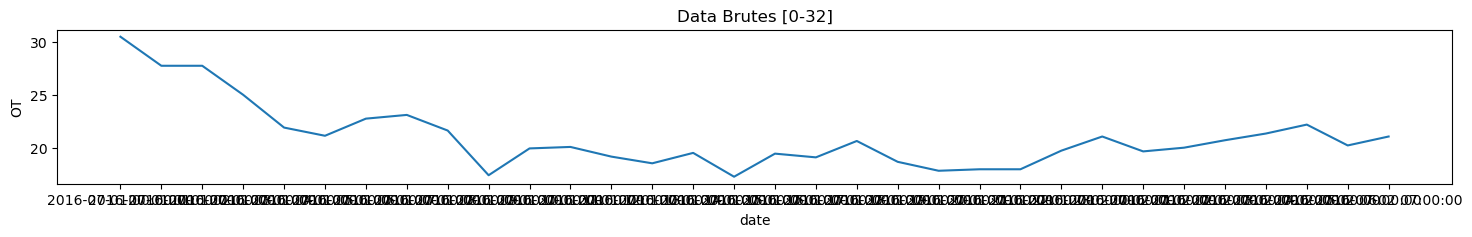

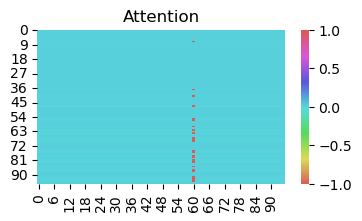

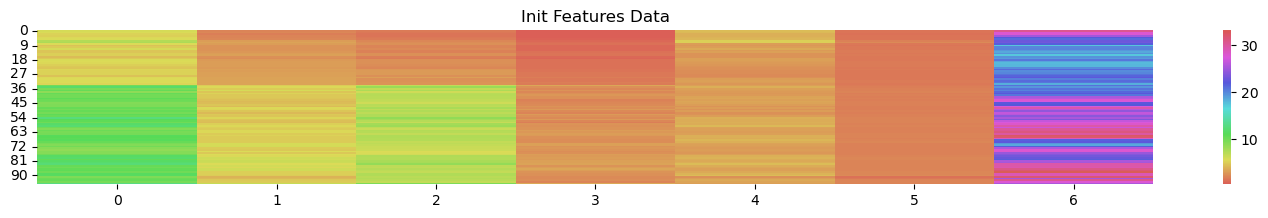

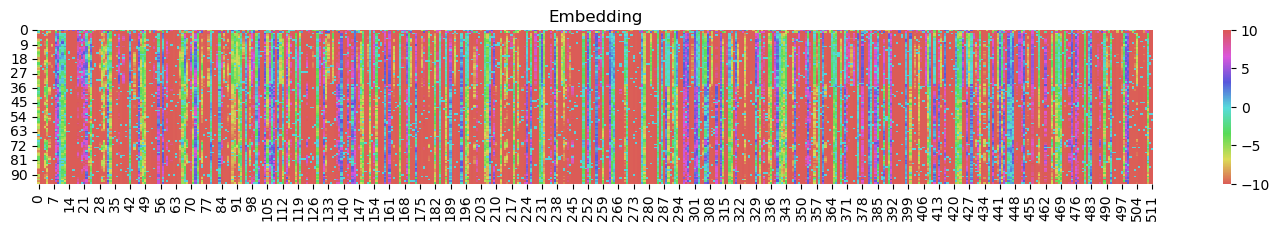

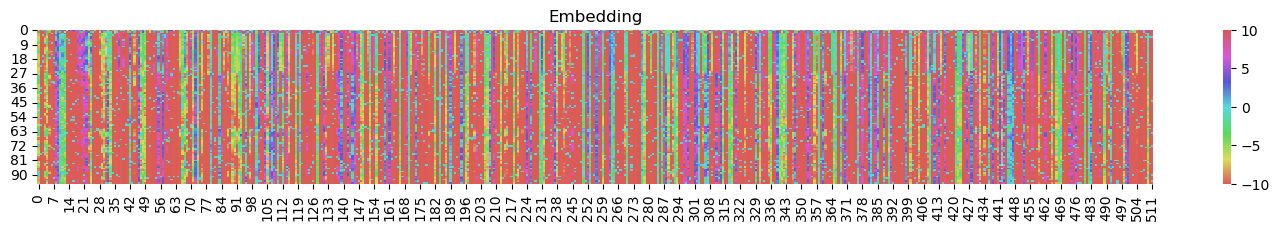

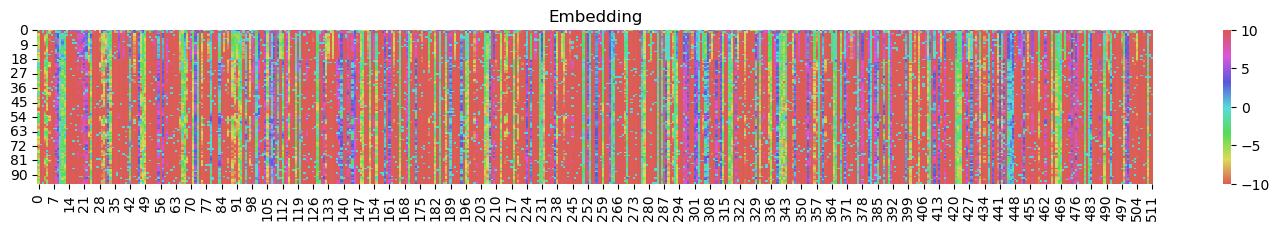

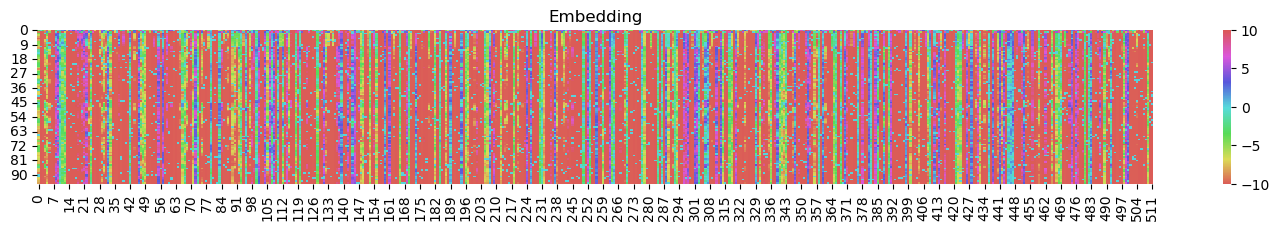

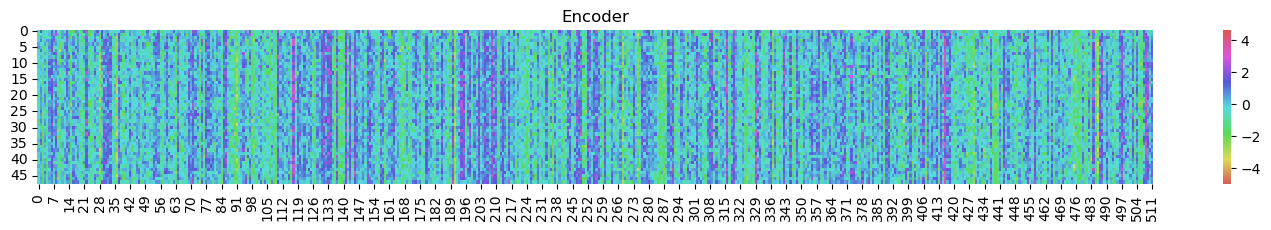

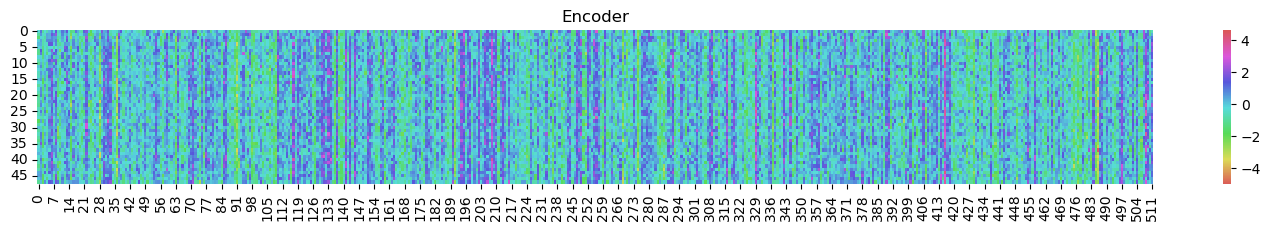

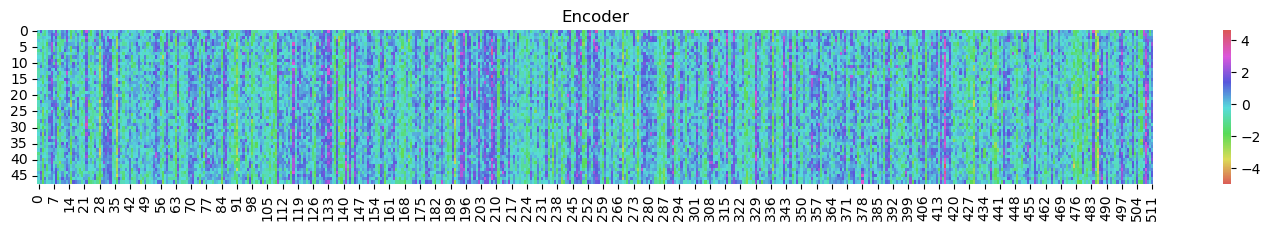

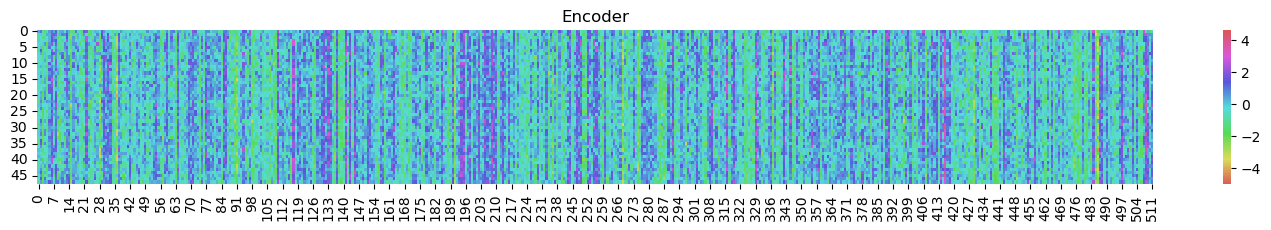

In [3]:
# Encoder
d_model = 512
HEAD = 8
RATE = 0.05
SEQ_LEN = 96
FACTOR = 5
BATCH_SIZE = 32
GLOBAL_SIZE = 32
N = 2
d_FF= 2048

tf.keras.backend.clear_session()

Xt, XtDate, Yt, YtDate, df_raw = getDataETTh1(batch_size=BATCH_SIZE, seq_len = SEQ_LEN, global_size = GLOBAL_SIZE)
#Embedding
encEmbFct = DataEmbedding(seq_len=SEQ_LEN, d_model=d_model,rate=RATE)
encEmb = encEmbFct(x=Xt, x_mark=XtDate, training=True)

e_layer = 4

encTest = EncoderInf( [ EncoderInfLayer( 
                        AttentionLayer(
                            ProbAttention(False,FACTOR,None,RATE,True)
                                ,d_model, HEAD, None, None, False)
                            ,d_model, RATE,d_FF) for _ in range(e_layer) 
                        ]                     ,
                    [ ConvLayer(seq_len=SEQ_LEN) for _ in range (e_layer - 1)
                    ])

out,attn = encTest(encEmb, training=True)
print(len(attn))

Xt_min = tf.reduce_min(Xt)
Xt_max = tf.reduce_max(Xt)
Out_min = tf.reduce_min(out)
Out_max = tf.reduce_max(out)
fig = plt.figure(figsize=(18,2))
sns.lineplot(x=df_raw['date'][:GLOBAL_SIZE],y=df_raw['OT'][:GLOBAL_SIZE]).set_title('Data Brutes [0-32]');
fig = plt.figure(figsize=(4,2))
sns.heatmap(attn[0][0,0,:,:], vmin=-1, vmax=1, cmap=sns.color_palette("hls", 256)).set_title('Attention');
fig = plt.figure(figsize=(18,2))
sns.heatmap(Xt[0,:,:], vmin=Xt_min, vmax=Xt_max, cmap=sns.color_palette("hls", 256)).set_title('Init Features Data');
for i in range(0,BATCH_SIZE,8):
    fig = plt.figure(figsize=(18,2))
    sns.heatmap(encEmb[i,:,:], vmin=-10, vmax=10, cmap=sns.color_palette("hls", 256)).set_title('Embedding');
for i in range(0,BATCH_SIZE,8):
    fig = plt.figure(figsize=(18,2))
    sns.heatmap(out[i,:,:], vmin=Out_min, vmax=Out_max, cmap=sns.color_palette("hls", 256)).set_title('Encoder');